# Step 5 — Advanced models: NOE-MLP and LSTM (simulation-trained)

**5SC28 — Unbalanced Disc, ANN identification (no $\omega$)**

We compare two "advanced" approaches to the NARX-MLP baseline of Step 3/4:

1. **NOE-MLP**: same architecture as the NARX winner, but trained with a **T-step simulation loss** (autoregressive unroll) starting from the NARX weights (warm-start).
2. **LSTM**: a recurrent network with a `n_init`-step teacher-forced warm-up followed by a `T`-step simulated unroll; trained from random init.

For each model family we sweep `T ∈ {20, 50, 100}` (6 trainings total).

**Regularization techniques applied** (all from the course):
- L2 weight decay (Adam `weight_decay`).
- Unit-circle penalty `λ_uc · mean((ŝ²+ĉ²-1)²)` to keep predictions on the manifold.
- Early stopping on **validation simulation** RMSE (not prediction).
- Warm-start (NOE) — a form of curriculum.

**Selection criterion**: best val SIM RMSE on $\theta$.


In [ ]:
import time, math, copy
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

REPO_DIR = Path(
    "/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/gym-unbalanced-disk-master/disc-benchmark-files"
)
WORK_DIR = Path(
    "/Users/davidedeleonardis/Documents/TU-e/1 anno/Q4/Machine learning for systems and control/Assigment/ML4S&C-assignment"
)
ARTIFACTS = WORK_DIR / 'artifacts'
SUBMISSIONS = WORK_DIR / 'submissions'
SUBMISSIONS.mkdir(exist_ok=True)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(0); np.random.seed(0)
print('device:', device)

device: mps


## 5.1 — Common helpers and data

In [2]:
def wrap_pi(x):
    return (x + np.pi) % (2 * np.pi) - np.pi

def rmse_from_sincos(s_pred, c_pred, s_true, c_true):
    th_p = np.arctan2(s_pred, c_pred)
    th_t = np.arctan2(s_true, c_true)
    return float(np.sqrt(np.mean(wrap_pi(th_p - th_t) ** 2)))

# Load processed signals from Step 2.
P = np.load(ARTIFACTS / 'step2_processed.npz')
u_tr_n, u_va_n = P['u_tr_n'], P['u_va_n']
sin_tr, cos_tr = P['sin_tr'], P['cos_tr']
sin_va, cos_va = P['sin_va'], P['cos_va']
th_tr,  th_va  = P['th_tr'],  P['th_va']
U_SCALE = float(P['U_SCALE'])
Ts      = float(P['Ts'])
print(f'Train: {len(u_tr_n)} samples   Val: {len(u_va_n)} samples')

# Convert to tensors once.
u_tr_t   = torch.from_numpy(u_tr_n.astype(np.float32)).to(device)
sin_tr_t = torch.from_numpy(sin_tr.astype(np.float32)).to(device)
cos_tr_t = torch.from_numpy(cos_tr.astype(np.float32)).to(device)
u_va_t   = torch.from_numpy(u_va_n.astype(np.float32)).to(device)
sin_va_t = torch.from_numpy(sin_va.astype(np.float32)).to(device)
cos_va_t = torch.from_numpy(cos_va.astype(np.float32)).to(device)


Train: 28000 samples   Val: 7000 samples


## 5.2 — NOE-MLP

The model is structurally identical to the Step 3 NARX-MLP. We re-define it here for self-containment, then warm-start from `best_narx.pt`.

The unroll is **fully vectorized** over the batch: the buffers $u\_buf$ (B, $n_b$), $s\_buf$, $c\_buf$ (B, $n_a$) are rolled with a `torch.cat` shift at each step. This is the only way to get reasonable MPS throughput for a T=100 unroll over a batch of 64.


In [3]:
class NARX_MLP(nn.Module):
    def __init__(self, in_dim, hidden=64, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

# --- NARX winner reference (Step 3) ---
ckpt_narx = torch.load(ARTIFACTS / 'best_narx.pt', map_location=device, weights_only=True)
NA = int(ckpt_narx['na']); NB = int(ckpt_narx['nb'])
HIDDEN = int(ckpt_narx['hidden']); IN_DIM = int(ckpt_narx['in_dim'])
print(f'NARX winner: na={NA}, nb={NB}, in_dim={IN_DIM}, hidden={HIDDEN}')


NARX winner: na=4, nb=6, in_dim=14, hidden=64


In [4]:
def unroll_narx_sim(model, u_init, sin_init, cos_init, u_future, na, nb):
    """Batched autoregressive unroll for the NARX-MLP.
    u_init  : (B, nb) — normalized past inputs (oldest first).
    sin_init: (B, na), cos_init: (B, na) — past (sin, cos) at lags na..1.
    u_future: (B, T) — normalized future inputs.
    Returns (pred_sin, pred_cos), each (B, T).
    """
    B, T = u_future.shape
    u_buf = u_init.clone()
    s_buf = sin_init.clone()
    c_buf = cos_init.clone()
    preds_s, preds_c = [], []
    for t in range(T):
        # Interleave sin, cos lag by lag: (B, 2*na)
        sc = torch.empty(B, 2 * na, device=u_buf.device, dtype=u_buf.dtype)
        sc[:, 0::2] = s_buf
        sc[:, 1::2] = c_buf
        phi = torch.cat([u_buf, sc], dim=1)
        y = model(phi)
        s_hat, c_hat = y[:, 0], y[:, 1]
        preds_s.append(s_hat); preds_c.append(c_hat)
        # Roll buffers: drop oldest, append newest.
        u_buf = torch.cat([u_buf[:, 1:], u_future[:, t:t+1]], dim=1)
        s_buf = torch.cat([s_buf[:, 1:], s_hat.unsqueeze(1)], dim=1)
        c_buf = torch.cat([c_buf[:, 1:], c_hat.unsqueeze(1)], dim=1)
    return torch.stack(preds_s, dim=1), torch.stack(preds_c, dim=1)


In [5]:
def sample_noe_batch(B, T, na, nb):
    """Sample B random training windows. Returns (u_init, sin_init, cos_init, u_future, sin_true, cos_true)."""
    n0 = max(na, nb)
    Ntr = u_tr_t.shape[0]
    # Valid starting indices k0 such that k0 - n0 >= 0 and k0 + T <= Ntr.
    k0 = torch.randint(low=n0, high=Ntr - T + 1, size=(B,), device=device)
    # Build index matrices.
    ar_u  = torch.arange(-nb, 0, device=device)
    ar_s  = torch.arange(-na, 0, device=device)
    ar_T  = torch.arange(T, device=device)
    idx_u_init  = k0[:, None] + ar_u           # (B, nb)
    idx_s_init  = k0[:, None] + ar_s           # (B, na)
    idx_future  = k0[:, None] + ar_T           # (B, T)
    u_init   = u_tr_t[idx_u_init]
    sin_init = sin_tr_t[idx_s_init]
    cos_init = cos_tr_t[idx_s_init]
    u_future = u_tr_t[idx_future]
    sin_true = sin_tr_t[idx_future]
    cos_true = cos_tr_t[idx_future]
    return u_init, sin_init, cos_init, u_future, sin_true, cos_true


In [6]:
def eval_val_sim_narx(model, na, nb):
    """Run full free-run on validation set, return RMSE on theta."""
    model.eval()
    skip = max(na, nb)
    Nv = u_va_t.shape[0]
    with torch.no_grad():
        # Single batch of size 1 spanning the whole val sequence.
        u_init = u_va_t[skip-nb:skip].unsqueeze(0)
        s_init = sin_va_t[skip-na:skip].unsqueeze(0)
        c_init = cos_va_t[skip-na:skip].unsqueeze(0)
        u_future = u_va_t[skip:].unsqueeze(0)
        ps, pc = unroll_narx_sim(model, u_init, s_init, c_init, u_future, na, nb)
    ps = ps.squeeze(0).cpu().numpy(); pc = pc.squeeze(0).cpu().numpy()
    return rmse_from_sincos(ps, pc, sin_va[skip:], cos_va[skip:])

def eval_val_pred_narx(model, na, nb):
    """Standard one-step prediction RMSE on val."""
    model.eval()
    n0 = max(na, nb); M = len(u_va_n) - n0
    ar_u = np.arange(-nb, 0); ar_th = np.arange(-na, 0)
    idx_u  = np.arange(n0, n0 + M)[:, None] + ar_u
    idx_th = np.arange(n0, n0 + M)[:, None] + ar_th
    Xu = u_va_n[idx_u]; Xs = sin_va[idx_th]; Xc = cos_va[idx_th]
    sc = np.empty((M, 2*na), dtype=np.float32)
    sc[:, 0::2] = Xs; sc[:, 1::2] = Xc
    X = np.concatenate([Xu, sc], axis=1).astype(np.float32)
    with torch.no_grad():
        Y = model(torch.from_numpy(X).to(device)).cpu().numpy()
    return rmse_from_sincos(Y[:, 0], Y[:, 1], sin_va[n0:], cos_va[n0:])


In [7]:
def train_noe(T_horizon, max_iters=2000, B=64, lr=5e-4, wd=1e-4,
              lambda_uc=1e-2, eval_every=100, patience=8, verbose=True):
    model = NARX_MLP(IN_DIM, hidden=HIDDEN).to(device)
    # Warm-start from NARX winner.
    model.load_state_dict(ckpt_narx['state_dict'])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=1/3, patience=4)

    best_sim = float('inf'); best_state = copy.deepcopy(model.state_dict()); bad = 0
    history = {'iter': [], 'train_loss': [], 'val_sim': []}

    t0 = time.time()
    for it in range(1, max_iters + 1):
        model.train()
        u_i, s_i, c_i, u_f, s_t, c_t = sample_noe_batch(B, T_horizon, NA, NB)
        ps, pc = unroll_narx_sim(model, u_i, s_i, c_i, u_f, NA, NB)
        mse = ((ps - s_t) ** 2 + (pc - c_t) ** 2).mean()
        uc  = ((ps ** 2 + pc ** 2 - 1.0) ** 2).mean()
        loss = mse + lambda_uc * uc
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if it % eval_every == 0:
            v = eval_val_sim_narx(model, NA, NB)
            sched.step(v)
            history['iter'].append(it); history['train_loss'].append(float(loss.item())); history['val_sim'].append(v)
            improved = v < best_sim - 1e-6
            if improved:
                best_sim = v
                best_state = copy.deepcopy(model.state_dict())
                bad = 0
            else:
                bad += 1
            if verbose:
                print(f'  T={T_horizon:>3} it={it:>4}  loss={loss.item():.4e}  val_sim={v:.4f} rad  '
                      f'best={best_sim:.4f}  bad={bad}')
            if bad >= patience:
                if verbose: print(f'  early stop at iter {it}')
                break

    model.load_state_dict(best_state)
    val_pred = eval_val_pred_narx(model, NA, NB)
    val_sim  = eval_val_sim_narx(model, NA, NB)
    return {
        'name': f'NOE-MLP (T={T_horizon})',
        'family': 'NOE',
        'T': T_horizon,
        'state_dict': best_state,
        'val_pred': val_pred,
        'val_sim':  val_sim,
        'history':  history,
        'time_s':   time.time() - t0,
    }

noe_results = []
for T_h in (20, 50, 100):
    print(f'\n--- Training NOE-MLP with T = {T_h} ---')
    res = train_noe(T_h)
    print(f'  -> val PRED = {res["val_pred"]:.4f} rad   val SIM = {res["val_sim"]:.4f} rad   [{res["time_s"]:.1f}s]')
    noe_results.append(res)



--- Training NOE-MLP with T = 20 ---
  T= 20 it= 100  loss=2.6879e-03  val_sim=0.1708 rad  best=0.1708  bad=0
  T= 20 it= 200  loss=2.2098e-03  val_sim=0.1125 rad  best=0.1125  bad=0
  T= 20 it= 300  loss=8.3453e-03  val_sim=0.2846 rad  best=0.1125  bad=1
  T= 20 it= 400  loss=2.1138e-03  val_sim=0.2508 rad  best=0.1125  bad=2
  T= 20 it= 500  loss=9.5595e-03  val_sim=0.1167 rad  best=0.1125  bad=3
  T= 20 it= 600  loss=8.8502e-03  val_sim=0.3570 rad  best=0.1125  bad=4
  T= 20 it= 700  loss=1.7072e-03  val_sim=0.1936 rad  best=0.1125  bad=5
  T= 20 it= 800  loss=1.4249e-03  val_sim=0.1161 rad  best=0.1125  bad=6
  T= 20 it= 900  loss=2.9819e-03  val_sim=0.1352 rad  best=0.1125  bad=7
  T= 20 it=1000  loss=7.3085e-04  val_sim=0.1286 rad  best=0.1125  bad=8
  early stop at iter 1000
  -> val PRED = 0.0060 rad   val SIM = 0.1125 rad   [25.5s]

--- Training NOE-MLP with T = 50 ---
  T= 50 it= 100  loss=7.6585e-03  val_sim=0.2136 rad  best=0.2136  bad=0
  T= 50 it= 200  loss=1.5790e-02  v

## 5.3 — LSTM model (random init, T-step simulation training)

Architecture: a single LSTM cell with hidden size 32, input dim 3 ($u$, $\sin\theta$, $\cos\theta$ at the past step), and a linear head $\mathbb{R}^{32}\to\mathbb{R}^2$.

Training pattern: at every window, first `n_init=10` steps are **teacher-forced** (true sin/cos as input) to warm up the hidden state; the next `T` steps are **simulated** (feed back the network's own predictions). Loss is computed on the `T` simulated outputs.

For inference on the prediction task we feed all 15 past observations through the LSTM and read the last output as the prediction of $\theta_k$.


In [8]:
class LSTMNarx(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.hidden = hidden
        self.cell = nn.LSTMCell(input_size=3, hidden_size=hidden)
        self.head = nn.Linear(hidden, 2)
    def init_state(self, B, device):
        h = torch.zeros(B, self.hidden, device=device)
        c = torch.zeros(B, self.hidden, device=device)
        return h, c

N_INIT = 10  # warm-up length in samples

def unroll_lstm_window(model, u_win, sin_win, cos_win, n_init, T):
    """u_win, sin_win, cos_win: (B, n_init + T)
    Returns pred_sin, pred_cos each (B, T) corresponding to time indices [n_init, n_init+T-1]."""
    B = u_win.shape[0]
    h, c = model.init_state(B, u_win.device)
    # Warm-up: teacher forcing for first n_init steps. Last output predicts time n_init.
    scored = []
    last_pred = None
    for t in range(n_init):
        x = torch.stack([u_win[:, t], sin_win[:, t], cos_win[:, t]], dim=-1)
        h, c = model.cell(x, (h, c))
    last_pred = model.head(h)            # predicts time n_init
    scored.append(last_pred)
    # Simulation phase: use last_pred as (sin, cos) input.
    for t in range(n_init, n_init + T - 1):
        x = torch.stack([u_win[:, t], last_pred[:, 0], last_pred[:, 1]], dim=-1)
        h, c = model.cell(x, (h, c))
        last_pred = model.head(h)        # predicts time t+1
        scored.append(last_pred)
    pred = torch.stack(scored, dim=1)    # (B, T, 2)
    return pred[..., 0], pred[..., 1]


In [9]:
def sample_lstm_batch(B, T):
    """Sample B random windows of length n_init + T."""
    L = N_INIT + T
    Ntr = u_tr_t.shape[0]
    k0 = torch.randint(low=0, high=Ntr - L + 1, size=(B,), device=device)
    ar = torch.arange(L, device=device)
    idx = k0[:, None] + ar
    return u_tr_t[idx], sin_tr_t[idx], cos_tr_t[idx]

@torch.no_grad()
def eval_val_sim_lstm(model):
    """Full free-run on validation set: warm-up first N_INIT, then simulate to the end."""
    model.eval()
    Nv = u_va_t.shape[0]
    T_eff = Nv - N_INIT
    u_win   = u_va_t.unsqueeze(0)
    sin_win = sin_va_t.unsqueeze(0)
    cos_win = cos_va_t.unsqueeze(0)
    ps, pc = unroll_lstm_window(model, u_win, sin_win, cos_win, N_INIT, T_eff)
    ps = ps.squeeze(0).cpu().numpy(); pc = pc.squeeze(0).cpu().numpy()
    return rmse_from_sincos(ps, pc, sin_va[N_INIT:], cos_va[N_INIT:])

@torch.no_grad()
def eval_val_pred_lstm(model):
    """One-step prediction RMSE on val: run LSTM teacher-forced over the whole val sequence,
    score the output at each step against the next true (sin, cos)."""
    model.eval()
    Nv = u_va_t.shape[0]
    h, c = model.init_state(1, device)
    preds_s = []; preds_c = []
    for t in range(Nv - 1):
        x = torch.stack([u_va_t[t:t+1], sin_va_t[t:t+1], cos_va_t[t:t+1]], dim=-1)
        h, c = model.cell(x, (h, c))
        y = model.head(h)
        preds_s.append(y[0, 0].item()); preds_c.append(y[0, 1].item())
    ps = np.array(preds_s); pc = np.array(preds_c)
    # output at step t predicts time t+1; warm-up: skip first N_INIT - 1.
    return rmse_from_sincos(ps[N_INIT-1:], pc[N_INIT-1:], sin_va[N_INIT:], cos_va[N_INIT:])


In [10]:
def train_lstm(T_horizon, max_iters=2500, B=64, lr=1e-3, wd=1e-4,
               lambda_uc=1e-2, eval_every=100, patience=8, verbose=True):
    model = LSTMNarx(hidden=32).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=1/3, patience=4)

    best_sim = float('inf'); best_state = copy.deepcopy(model.state_dict()); bad = 0
    history = {'iter': [], 'train_loss': [], 'val_sim': []}

    t0 = time.time()
    for it in range(1, max_iters + 1):
        model.train()
        u_w, s_w, c_w = sample_lstm_batch(B, T_horizon)
        ps, pc = unroll_lstm_window(model, u_w, s_w, c_w, N_INIT, T_horizon)
        s_t = s_w[:, N_INIT:N_INIT + T_horizon]; c_t = c_w[:, N_INIT:N_INIT + T_horizon]
        mse = ((ps - s_t) ** 2 + (pc - c_t) ** 2).mean()
        uc  = ((ps ** 2 + pc ** 2 - 1.0) ** 2).mean()
        loss = mse + lambda_uc * uc
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if it % eval_every == 0:
            v = eval_val_sim_lstm(model)
            sched.step(v)
            history['iter'].append(it); history['train_loss'].append(float(loss.item())); history['val_sim'].append(v)
            improved = v < best_sim - 1e-6
            if improved:
                best_sim = v
                best_state = copy.deepcopy(model.state_dict())
                bad = 0
            else:
                bad += 1
            if verbose:
                print(f'  T={T_horizon:>3} it={it:>4}  loss={loss.item():.4e}  val_sim={v:.4f} rad  '
                      f'best={best_sim:.4f}  bad={bad}')
            if bad >= patience:
                if verbose: print(f'  early stop at iter {it}')
                break

    model.load_state_dict(best_state)
    val_pred = eval_val_pred_lstm(model)
    val_sim  = eval_val_sim_lstm(model)
    return {
        'name': f'LSTM (T={T_horizon})',
        'family': 'LSTM',
        'T': T_horizon,
        'state_dict': best_state,
        'val_pred': val_pred,
        'val_sim':  val_sim,
        'history':  history,
        'time_s':   time.time() - t0,
    }

lstm_results = []
for T_h in (20, 50, 100):
    print(f'\n--- Training LSTM with T = {T_h} ---')
    res = train_lstm(T_h)
    print(f'  -> val PRED = {res["val_pred"]:.4f} rad   val SIM = {res["val_sim"]:.4f} rad   [{res["time_s"]:.1f}s]')
    lstm_results.append(res)



--- Training LSTM with T = 20 ---
  T= 20 it= 100  loss=1.1783e-01  val_sim=0.4318 rad  best=0.4318  bad=0
  T= 20 it= 200  loss=2.4687e-02  val_sim=0.2234 rad  best=0.2234  bad=0
  T= 20 it= 300  loss=7.7133e-03  val_sim=0.1293 rad  best=0.1293  bad=0
  T= 20 it= 400  loss=5.1446e-03  val_sim=0.1072 rad  best=0.1072  bad=0
  T= 20 it= 500  loss=3.8150e-03  val_sim=0.0981 rad  best=0.0981  bad=0
  T= 20 it= 600  loss=2.2726e-03  val_sim=0.1099 rad  best=0.0981  bad=1
  T= 20 it= 700  loss=9.4111e-04  val_sim=0.1052 rad  best=0.0981  bad=2
  T= 20 it= 800  loss=1.8522e-03  val_sim=0.1029 rad  best=0.0981  bad=3
  T= 20 it= 900  loss=1.5722e-03  val_sim=0.1021 rad  best=0.0981  bad=4
  T= 20 it=1000  loss=8.9026e-04  val_sim=0.0972 rad  best=0.0972  bad=0
  T= 20 it=1100  loss=1.3963e-03  val_sim=0.1122 rad  best=0.0972  bad=1
  T= 20 it=1200  loss=1.0669e-03  val_sim=0.1040 rad  best=0.0972  bad=2
  T= 20 it=1300  loss=1.0591e-03  val_sim=0.0822 rad  best=0.0822  bad=0
  T= 20 it=1400 

## 5.4 — Comparison table

In [11]:
# Include the NARX baseline (Step 4) reading val metrics from ckpt.
NARX_VAL_PRED = 0.0050  # from Step 4 self-check
NARX_VAL_SIM  = 0.1494  # from Step 4 self-check

all_results = (
    [{'name': 'NARX-MLP (Step 3)', 'family': 'NARX', 'T': '-',
      'val_pred': NARX_VAL_PRED, 'val_sim': NARX_VAL_SIM, 'time_s': float('nan')}]
    + noe_results + lstm_results
)

print(f'{"name":<22} {"T":>4} {"val_PRED [rad]":>15} {"val_SIM [rad]":>14} {"val_SIM [deg]":>14}')
print('-' * 75)
for r in all_results:
    print(f'{r["name"]:<22} {str(r["T"]):>4} {r["val_pred"]:>15.4f} {r["val_sim"]:>14.4f} {np.rad2deg(r["val_sim"]):>14.2f}')
print()
print('Repo baselines for reference:')
print(f'{"Linear ARX":<22} {"-":>4} {0.00665:>15.4f} {0.255:>14.4f} {14.6:>14.2f}')
print(f'{"Good NN":<22} {"-":>4} {0.00382:>15.4f} {0.0271:>14.4f} {1.55:>14.2f}')
print(f'{"Lower bound (sim)":<22} {"-":>4} {"-":>15} {0.0195:>14.4f} {1.12:>14.2f}')


name                      T  val_PRED [rad]  val_SIM [rad]  val_SIM [deg]
---------------------------------------------------------------------------
NARX-MLP (Step 3)         -          0.0050         0.1494           8.56
NOE-MLP (T=20)           20          0.0060         0.1125           6.45
NOE-MLP (T=50)           50          0.0056         0.0959           5.50
NOE-MLP (T=100)         100          0.0073         0.1112           6.37
LSTM (T=20)              20          0.0277         0.0639           3.66
LSTM (T=50)              50          0.0319         0.0587           3.36
LSTM (T=100)            100          0.0384         0.0622           3.56

Repo baselines for reference:
Linear ARX                -          0.0066         0.2550          14.60
Good NN                   -          0.0038         0.0271           1.55
Lower bound (sim)         -               -         0.0195           1.12


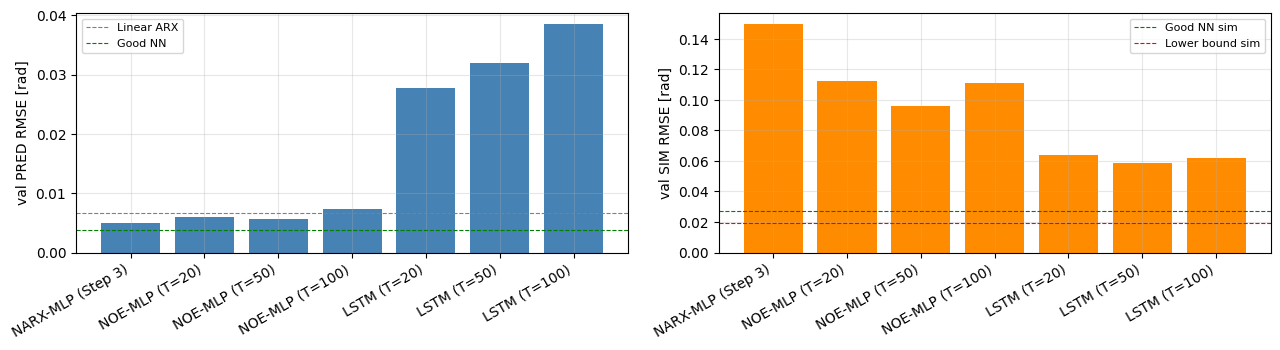

In [12]:
# Bar chart comparison of val SIM RMSE.
names = [r['name'] for r in all_results]
sims  = [r['val_sim'] for r in all_results]
preds = [r['val_pred'] for r in all_results]
fig, ax = plt.subplots(1, 2, figsize=(13, 3.6))
ax[0].bar(range(len(names)), preds, color='steelblue')
ax[0].axhline(0.00665, color='gray', ls='--', lw=0.8, label='Linear ARX')
ax[0].axhline(0.00382, color='green', ls='--', lw=0.8, label='Good NN')
ax[0].set_xticks(range(len(names))); ax[0].set_xticklabels(names, rotation=30, ha='right')
ax[0].set_ylabel('val PRED RMSE [rad]'); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)
ax[1].bar(range(len(names)), sims, color='darkorange')
ax[1].axhline(0.0271, color='green', ls='--', lw=0.8, label='Good NN sim')
ax[1].axhline(0.0195, color='red',   ls='--', lw=0.8, label='Lower bound sim')
ax[1].set_xticks(range(len(names))); ax[1].set_xticklabels(names, rotation=30, ha='right')
ax[1].set_ylabel('val SIM RMSE [rad]'); ax[1].grid(alpha=0.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5.5 — Pick winner, free-run plot, save submission files

In [13]:
# Winner = best val SIM (excluding NARX baseline).
candidates = noe_results + lstm_results
winner = min(candidates, key=lambda r: r['val_sim'])
print(f'WINNER: {winner["name"]}  val_pred={winner["val_pred"]:.4f}  val_sim={winner["val_sim"]:.4f} rad ({np.rad2deg(winner["val_sim"]):.2f}\u00b0)')

# Rebuild winning model.
if winner['family'] == 'NOE':
    win_model = NARX_MLP(IN_DIM, hidden=HIDDEN).to(device)
else:
    win_model = LSTMNarx(hidden=32).to(device)
win_model.load_state_dict(winner['state_dict']); win_model.eval()


WINNER: LSTM (T=50)  val_pred=0.0319  val_sim=0.0587 rad (3.36°)


LSTMNarx(
  (cell): LSTMCell(3, 32)
  (head): Linear(in_features=32, out_features=2, bias=True)
)

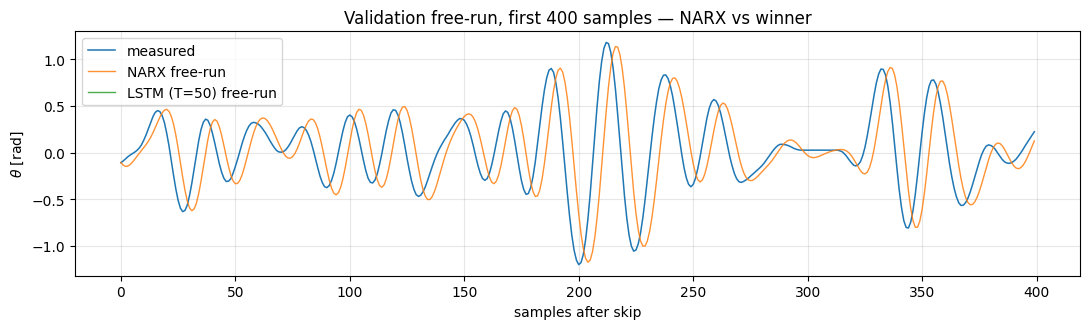

In [14]:
# Free-run plot: NARX baseline vs winner on the first 400 val samples.
# NARX baseline (rebuild for plotting).
narx = NARX_MLP(IN_DIM, hidden=HIDDEN).to(device)
narx.load_state_dict(ckpt_narx['state_dict']); narx.eval()

with torch.no_grad():
    skip = max(NA, NB)
    u_init = u_va_t[skip-NB:skip].unsqueeze(0)
    s_init = sin_va_t[skip-NA:skip].unsqueeze(0)
    c_init = cos_va_t[skip-NA:skip].unsqueeze(0)
    u_future = u_va_t[skip:].unsqueeze(0)
    ps_n, pc_n = unroll_narx_sim(narx, u_init, s_init, c_init, u_future, NA, NB)
    th_narx = np.arctan2(ps_n.squeeze(0).cpu().numpy(), pc_n.squeeze(0).cpu().numpy())

    if winner['family'] == 'NOE':
        ps_w, pc_w = unroll_narx_sim(win_model, u_init, s_init, c_init, u_future, NA, NB)
        th_win = np.arctan2(ps_w.squeeze(0).cpu().numpy(), pc_w.squeeze(0).cpu().numpy())
        x0 = skip
    else:
        Nv = u_va_t.shape[0]
        ps_w, pc_w = unroll_lstm_window(win_model, u_va_t.unsqueeze(0), sin_va_t.unsqueeze(0),
                                         cos_va_t.unsqueeze(0), N_INIT, Nv - N_INIT)
        th_win = np.arctan2(ps_w.squeeze(0).cpu().numpy(), pc_w.squeeze(0).cpu().numpy())
        x0 = N_INIT

n_show = 400
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(th_va[x0:x0+n_show],   label='measured', lw=1.1)
ax.plot(th_narx[:n_show],      label='NARX free-run', lw=1.0, alpha=0.85)
if winner['family'] == 'NOE':
    ax.plot(th_win[:n_show],   label=f'{winner["name"]} free-run', lw=1.0, alpha=0.85)
else:
    ax.plot(th_win[skip-N_INIT:skip-N_INIT+n_show],
            label=f'{winner["name"]} free-run', lw=1.0, alpha=0.85)
ax.set_xlabel('samples after skip'); ax.set_ylabel(r'$\theta$ [rad]'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Validation free-run, first 400 samples — NARX vs winner')
plt.tight_layout(); plt.show()


In [15]:
# Save winner.
save_dict = {
    'family': winner['family'],
    'T': winner['T'],
    'state_dict': winner['state_dict'],
    'val_pred': winner['val_pred'],
    'val_sim':  winner['val_sim'],
    'U_SCALE':  U_SCALE,
}
if winner['family'] == 'NOE':
    save_dict.update({'na': NA, 'nb': NB, 'in_dim': IN_DIM, 'hidden': HIDDEN})
else:
    save_dict.update({'n_init': N_INIT, 'lstm_hidden': 32})
torch.save(save_dict, ARTIFACTS / 'best_advanced.pt')
print('Saved', ARTIFACTS / 'best_advanced.pt')


Saved /Users/davidedeleonardis/Desktop/ml-control-project/artifacts/best_advanced.pt


### Hidden test submission with the winner

Same protocol as Step 4 (prediction + simulation) but using the advanced model.


In [16]:
test_pred = np.load(REPO_DIR / 'hidden-test-prediction-submission-file.npz')
upast  = test_pred['upast']
thpast = test_pred['thpast']
Ntp = upast.shape[0]

if winner['family'] == 'NOE':
    u_win  = (upast[:, -NB:] / U_SCALE).astype(np.float32)
    sin_w  = np.sin(thpast[:, -NA:]).astype(np.float32)
    cos_w  = np.cos(thpast[:, -NA:]).astype(np.float32)
    sc = np.empty((Ntp, 2 * NA), dtype=np.float32)
    sc[:, 0::2] = sin_w; sc[:, 1::2] = cos_w
    Phi = np.concatenate([u_win, sc], axis=1)
    with torch.no_grad():
        Y = win_model(torch.from_numpy(Phi).to(device)).cpu().numpy()
    th_pred_test = np.arctan2(Y[:, 0], Y[:, 1])
else:
    # LSTM: run cell over the 15 past samples per test point, read final output as prediction for k.
    u_n = (upast / U_SCALE).astype(np.float32)
    s_n = np.sin(thpast).astype(np.float32)
    c_n = np.cos(thpast).astype(np.float32)
    Up = torch.from_numpy(u_n).to(device)
    Sp = torch.from_numpy(s_n).to(device)
    Cp = torch.from_numpy(c_n).to(device)
    with torch.no_grad():
        h, c = win_model.init_state(Ntp, device)
        for t in range(upast.shape[1]):
            x = torch.stack([Up[:, t], Sp[:, t], Cp[:, t]], dim=-1)
            h, c = win_model.cell(x, (h, c))
        Y = win_model.head(h).cpu().numpy()
    th_pred_test = np.arctan2(Y[:, 0], Y[:, 1])

tag = 'noe' if winner['family'] == 'NOE' else 'lstm'
out_pred = SUBMISSIONS / f'{tag}-prediction-submission-file.npz'
np.savez(out_pred, upast=upast, thpast=thpast, thnow=th_pred_test)
print('Saved', out_pred, '  range:', th_pred_test.min(), th_pred_test.max())


Saved /Users/davidedeleonardis/Desktop/ml-control-project/submissions/lstm-prediction-submission-file.npz   range: -1.3861283 1.4935293


In [17]:
test_sim = np.load(REPO_DIR / 'hidden-test-simulation-submission-file.npz')
u_sim_raw = test_sim['u']
th_sim_seed = test_sim['th'].copy()
u_sim_n = (u_sim_raw / U_SCALE).astype(np.float32)
sin_seed = np.sin(th_sim_seed).astype(np.float32)
cos_seed = np.cos(th_sim_seed).astype(np.float32)

if winner['family'] == 'NOE':
    skip_sim = 50
    u_t = torch.from_numpy(u_sim_n).to(device)
    s_t = torch.from_numpy(sin_seed).to(device)
    c_t = torch.from_numpy(cos_seed).to(device)
    with torch.no_grad():
        u_init   = u_t[skip_sim - NB:skip_sim].unsqueeze(0)
        s_init   = s_t[skip_sim - NA:skip_sim].unsqueeze(0)
        c_init   = c_t[skip_sim - NA:skip_sim].unsqueeze(0)
        u_future = u_t[skip_sim:].unsqueeze(0)
        ps, pc = unroll_narx_sim(win_model, u_init, s_init, c_init, u_future, NA, NB)
    th_after = np.arctan2(ps.squeeze(0).cpu().numpy(), pc.squeeze(0).cpu().numpy())
    th_sim_full = np.concatenate([th_sim_seed[:skip_sim], th_after])
else:
    # LSTM: warm up on first 50 true samples, then free-run for the rest using future u.
    Nsim = len(u_sim_n)
    skip_sim = 50
    Up = torch.from_numpy(u_sim_n).to(device).unsqueeze(0)
    Sp = torch.from_numpy(sin_seed).to(device).unsqueeze(0)
    Cp = torch.from_numpy(cos_seed).to(device).unsqueeze(0)
    with torch.no_grad():
        h, c = win_model.init_state(1, device)
        # Teacher-force on the first 50 seeded samples.
        for t in range(skip_sim):
            x = torch.stack([Up[:, t], Sp[:, t], Cp[:, t]], dim=-1)
            h, c = win_model.cell(x, (h, c))
        last_pred = win_model.head(h)
        # Free-run for the remaining samples.
        out_s = []; out_c = []
        for t in range(skip_sim, Nsim):
            x = torch.stack([Up[:, t], last_pred[:, 0], last_pred[:, 1]], dim=-1)
            h, c = win_model.cell(x, (h, c))
            last_pred = win_model.head(h)
            out_s.append(last_pred[0, 0].item()); out_c.append(last_pred[0, 1].item())
    th_after = np.arctan2(np.array(out_s), np.array(out_c))
    th_sim_full = np.concatenate([th_sim_seed[:skip_sim], th_after])

out_sim = SUBMISSIONS / f'{tag}-simulation-submission-file.npz'
np.savez(out_sim, th=th_sim_full, u=u_sim_raw)
print('Saved', out_sim, '  range:', th_sim_full.min(), th_sim_full.max())


Saved /Users/davidedeleonardis/Desktop/ml-control-project/submissions/lstm-simulation-submission-file.npz   range: -1.6217068617436574 1.7459146860591432


---
**End of Step 5.**

Final deliverables:
- NARX-MLP baseline (Step 3): `submissions/narx-mlp-*.npz`
- Advanced winner: `submissions/{noe,lstm}-*.npz`
- All trained weights in `artifacts/`
